#Import Library

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Import Data

In [2]:
df = pd.read_csv('/content/CAR DETAILS FROM CAR DEKHO.csv')
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner


#Data Understanding

In [3]:
df.shape

(4340, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [5]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [6]:
df['name'].unique()

array(['Maruti 800 AC', 'Maruti Wagon R LXI Minor',
       'Hyundai Verna 1.6 SX', ..., 'Mahindra Verito 1.5 D6 BSIII',
       'Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV',
       'Hyundai i20 Magna 1.4 CRDi'], dtype=object)

In [7]:
df['fuel'].unique()

array(['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric'], dtype=object)

In [8]:
df['seller_type'].unique()

array(['Individual', 'Dealer', 'Trustmark Dealer'], dtype=object)

In [9]:
df['transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [10]:
df['owner'].unique()

array(['First Owner', 'Second Owner', 'Fourth & Above Owner',
       'Third Owner', 'Test Drive Car'], dtype=object)

#Data Cleaning

In [11]:
#copy data
df_clean = df.copy()

In [12]:
#Duplicate
df_clean.duplicated().sum()

np.int64(763)

In [13]:
df_clean = df_clean.drop_duplicates()

In [14]:
#missing values
df_clean.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


#Data Manipulation

In [15]:
#ekstrak kolom name menjadi brand
df_clean['brand'] = df_clean['name'].str.split().str[0]
df_clean = df_clean.drop(columns=['name'])

In [16]:
df_clean

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand
0,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti
1,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti
2,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun
4,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda
...,...,...,...,...,...,...,...,...
4335,2014,409999,80000,Diesel,Individual,Manual,Second Owner,Hyundai
4336,2014,409999,80000,Diesel,Individual,Manual,Second Owner,Hyundai
4337,2009,110000,83000,Petrol,Individual,Manual,Second Owner,Maruti
4338,2016,865000,90000,Diesel,Individual,Manual,First Owner,Hyundai


In [17]:
df_clean['brand'].unique()

array(['Maruti', 'Hyundai', 'Datsun', 'Honda', 'Tata', 'Chevrolet',
       'Toyota', 'Jaguar', 'Mercedes-Benz', 'Audi', 'Skoda', 'Jeep',
       'BMW', 'Mahindra', 'Ford', 'Nissan', 'Renault', 'Fiat',
       'Volkswagen', 'Volvo', 'Mitsubishi', 'Land', 'Daewoo', 'MG',
       'Force', 'Isuzu', 'OpelCorsa', 'Ambassador', 'Kia'], dtype=object)

In [18]:
#ekstrak kolom year menjadi car_age
import datetime
current_year = datetime.datetime.now().year
df_clean['car_age'] = current_year - df_clean['year']
df_clean = df_clean.drop(columns=['year'])
df_clean

,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,car_age
0,60000,70000,Petrol,Individual,Manual,First Owner,Maruti,18
1,135000,50000,Petrol,Individual,Manual,First Owner,Maruti,18
2,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai,13
3,250000,46000,Petrol,Individual,Manual,First Owner,Datsun,8
4,450000,141000,Diesel,Individual,Manual,Second Owner,Honda,11
...,...,...,...,...,...,...,...,...
4335,409999,80000,Diesel,Individual,Manual,Second Owner,Hyundai,11
4336,409999,80000,Diesel,Individual,Manual,Second Owner,Hyundai,11
4337,110000,83000,Petrol,Individual,Manual,Second Owner,Maruti,16
4338,865000,90000,Diesel,Individual,Manual,First Owner,Hyundai,9


#EDA

In [19]:
df_clean['brand'].value_counts()

,count
brand,
Maruti,1072
Hyundai,637
Mahindra,328
Tata,308
Ford,220
Honda,216
Toyota,170
Chevrolet,151
Renault,110


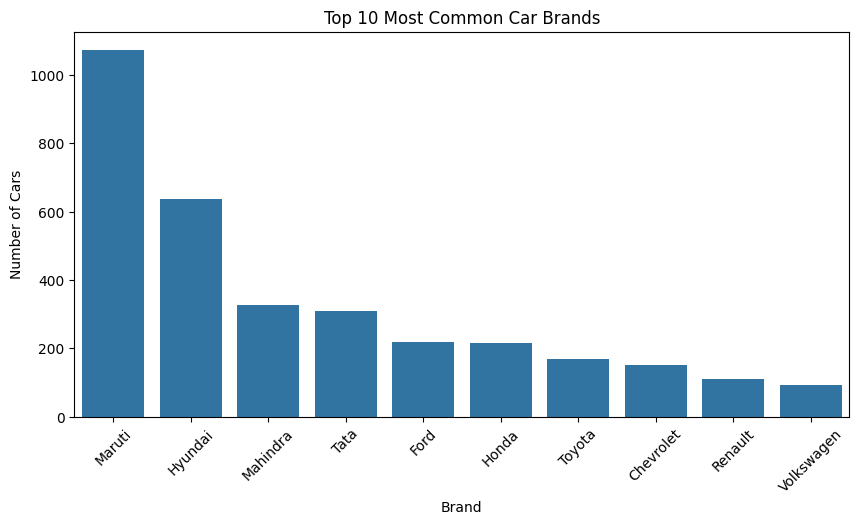

In [20]:
#Top 10 Brand
brand_counts = df_clean['brand'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=brand_counts.index, y=brand_counts.values)
plt.title('Top 10 Most Common Car Brands')
plt.xlabel('Brand')
plt.ylabel('Number of Cars')
plt.xticks(rotation=45)
plt.show()

In [21]:
#Car Age
df_clean['car_age'].value_counts()

,count
car_age,
8,346
13,338
10,332
11,321
12,298
7,295
9,283
14,247
15,210


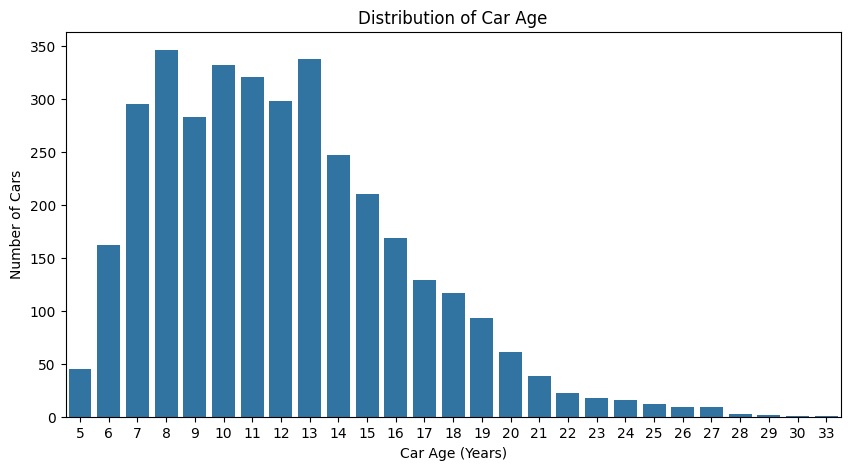

In [22]:
plt.figure(figsize=(10,5))
sns.countplot(x='car_age', data=df_clean, order=sorted(df_clean['car_age'].unique()))
plt.title('Distribution of Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Number of Cars')
plt.show()


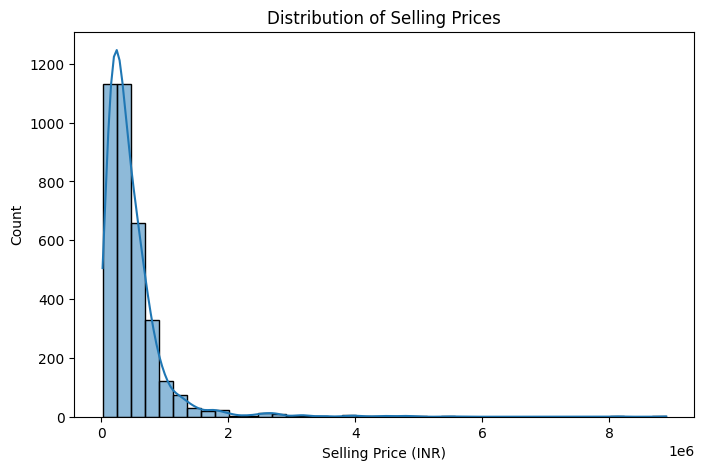

In [23]:
#Distribusi Harga
plt.figure(figsize=(8,5))
sns.histplot(df_clean['selling_price'], bins=40, kde=True)
plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price (INR)')
plt.ylabel('Count')
plt.show()

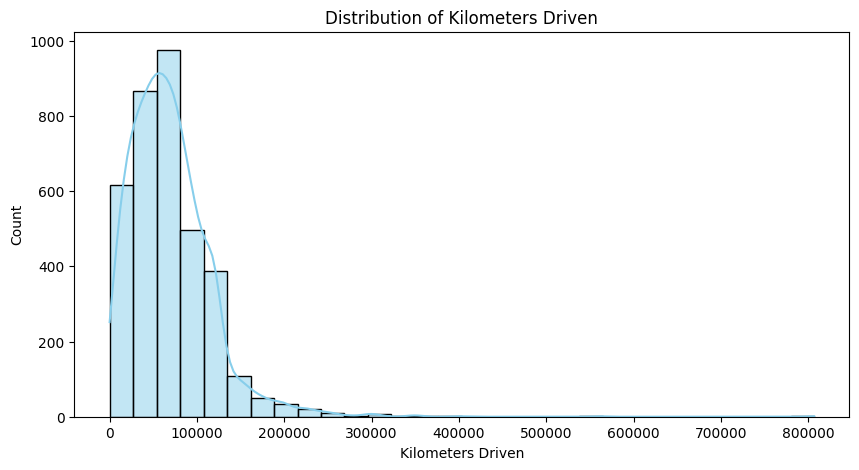

In [24]:
#Distribusi km_driven
plt.figure(figsize=(10,5))
sns.histplot(df_clean['km_driven'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Count')
plt.show()

/tmp/ipython-input-959503269.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='fuel', palette='Set2')


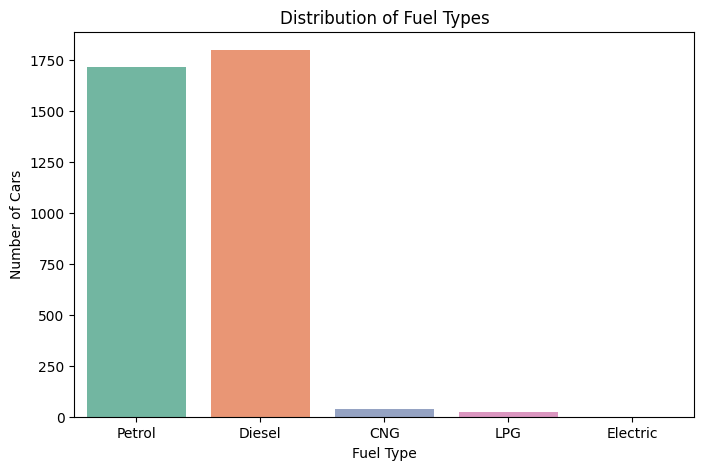

In [25]:
#Distribusi Fuel Type
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x='fuel', palette='Set2')
plt.title('Distribution of Fuel Types')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Cars')
plt.show()

/tmp/ipython-input-3676026188.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='owner', palette='Pastel2')


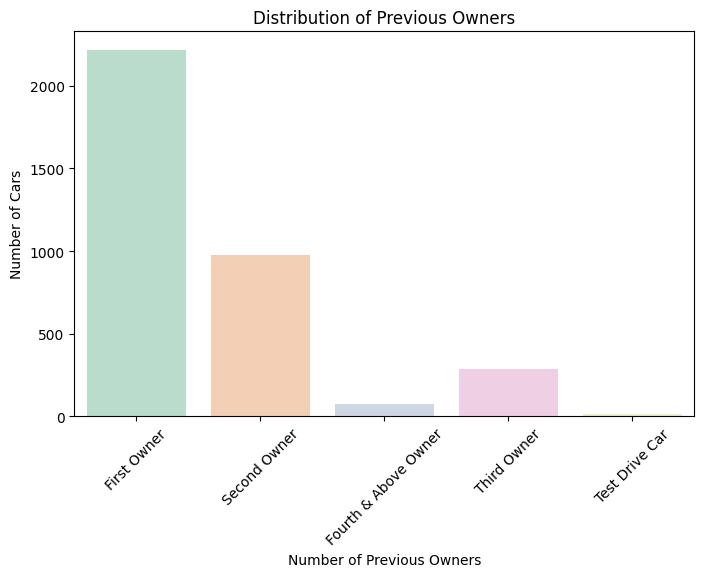

In [26]:
#Distribusi Owner
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x='owner', palette='Pastel2')
plt.title('Distribution of Previous Owners')
plt.xlabel('Number of Previous Owners')
plt.ylabel('Number of Cars')
plt.xticks(rotation=45)
plt.show()

/tmp/ipython-input-2990440762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='transmission', palette='cool')


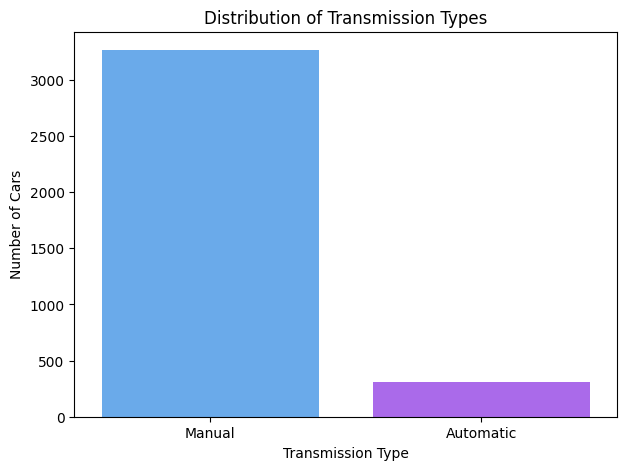

In [27]:
#Transmission
plt.figure(figsize=(7,5))
sns.countplot(data=df_clean, x='transmission', palette='cool')
plt.title('Distribution of Transmission Types')
plt.xlabel('Transmission Type')
plt.ylabel('Number of Cars')
plt.show()

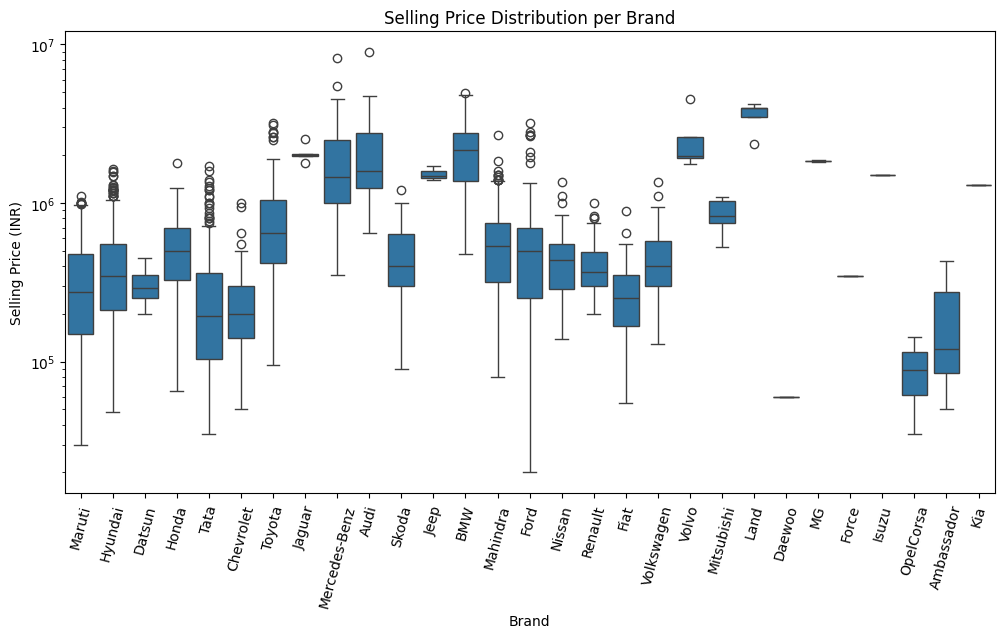

<Figure size 640x480 with 0 Axes>

In [28]:
#Price per brand
plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean, x='brand', y='selling_price')
plt.title('Selling Price Distribution per Brand')
plt.xlabel('Brand')
plt.ylabel('Selling Price (INR)')
plt.xticks(rotation=75)
plt.yscale('log')
plt.show()

plt.savefig("boxplot_brand_tier.png", dpi=300, bbox_inches='tight')  # simpan di folder kerja colab
plt.show()

In [29]:
from google.colab import files
files.download("boxplot_brand_tier.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Mapping Brand Tier

In [30]:
high_tier = ['Mercedes-Benz', 'BMW', 'Audi', 'Jaguar', 'Volvo']
mid_tier = ['Toyota', 'Honda', 'Hyundai', 'Skoda', 'Mahindra', 'Jeep']
low_tier = ['Maruti', 'Tata', 'Renault', 'Datsun', 'Ford', 'Nissan', 'Chevrolet']
other_tier = ['Land', 'MG', 'Daewoo', 'Force', 'Isuzu', 'OpelCorsa', 'Ambassador', 'Kia']

def brand_tier(brand):
    if brand in high_tier:
        return 'High'
    elif brand in mid_tier:
        return 'Mid'
    elif brand in low_tier:
        return 'Low'
    else:
        return 'Other'

df_clean['brand_tier'] = df_clean['brand'].apply(brand_tier)

In [31]:
df_clean['brand_tier'].value_counts()

,count
brand_tier,
Low,1942
Mid,1403
Other,146
High,86


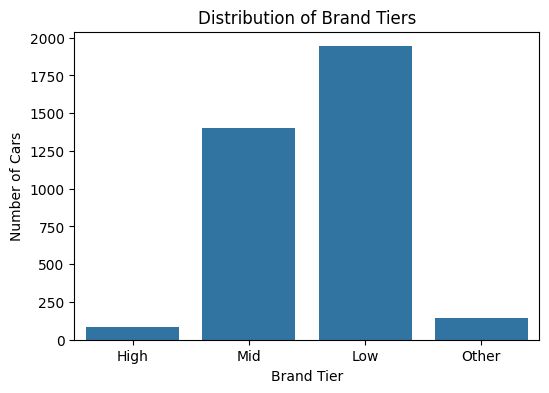

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='brand_tier', data=df_clean, order=['High', 'Mid', 'Low', 'Other'])
plt.title('Distribution of Brand Tiers')
plt.xlabel('Brand Tier')
plt.ylabel('Number of Cars')
plt.show()

In [33]:
df_clean.drop('brand', axis=1, inplace=True)

In [34]:
df_clean.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age,brand_tier
0,60000,70000,Petrol,Individual,Manual,First Owner,18,Low
1,135000,50000,Petrol,Individual,Manual,First Owner,18,Low
2,600000,100000,Diesel,Individual,Manual,First Owner,13,Mid
3,250000,46000,Petrol,Individual,Manual,First Owner,8,Low
4,450000,141000,Diesel,Individual,Manual,Second Owner,11,Mid


#Handling outlier?

#Separate target and feature

In [35]:
X = df_clean.drop(columns='selling_price')
y = df_clean['selling_price']

#Feature Engineering

In [36]:
#Label encoder for brand_tier
brand_tier_map = {'Low': 0, 'Mid': 1, 'High': 2, 'Other': 3}
X['brand_tier'] = X['brand_tier'].map(brand_tier_map)

In [37]:
#One Hot encoder for other feature
categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True).astype(int)

In [38]:
X

,km_driven,car_age,brand_tier,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,70000,18,0,0,0,0,1,1,0,1,0,0,0,0
1,50000,18,0,0,0,0,1,1,0,1,0,0,0,0
2,100000,13,1,1,0,0,0,1,0,1,0,0,0,0
3,46000,8,0,0,0,0,1,1,0,1,0,0,0,0
4,141000,11,1,1,0,0,0,1,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4335,80000,11,1,1,0,0,0,1,0,1,0,1,0,0
4336,80000,11,1,1,0,0,0,1,0,1,0,1,0,0
4337,83000,16,0,0,0,0,1,1,0,1,0,1,0,0
4338,90000,9,1,1,0,0,0,1,0,1,0,0,0,0


#Split train-test

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

#Multicollinearity test


In [40]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
print(vif_data)

                         Feature        VIF
0                        car_age  13.568866
1            transmission_Manual  11.575503
2                    fuel_Diesel  10.368378
3                    fuel_Petrol  10.204910
4         seller_type_Individual   5.434719
5                      km_driven   4.593682
6             owner_Second Owner   1.751473
7                     brand_tier   1.735483
8              owner_Third Owner   1.320928
9                       fuel_LPG   1.144440
10    owner_Fourth & Above Owner   1.115764
11  seller_type_Trustmark Dealer   1.048798
12          owner_Test Drive Car   1.036911
13                 fuel_Electric   1.006901


In [41]:
#drop
X_reduced = X.drop(columns=['fuel_Petrol'])

In [42]:
corr = X_reduced[['car_age', 'km_driven']].corr()
print(corr)

           car_age  km_driven
car_age    1.00000    0.41749
km_driven  0.41749    1.00000


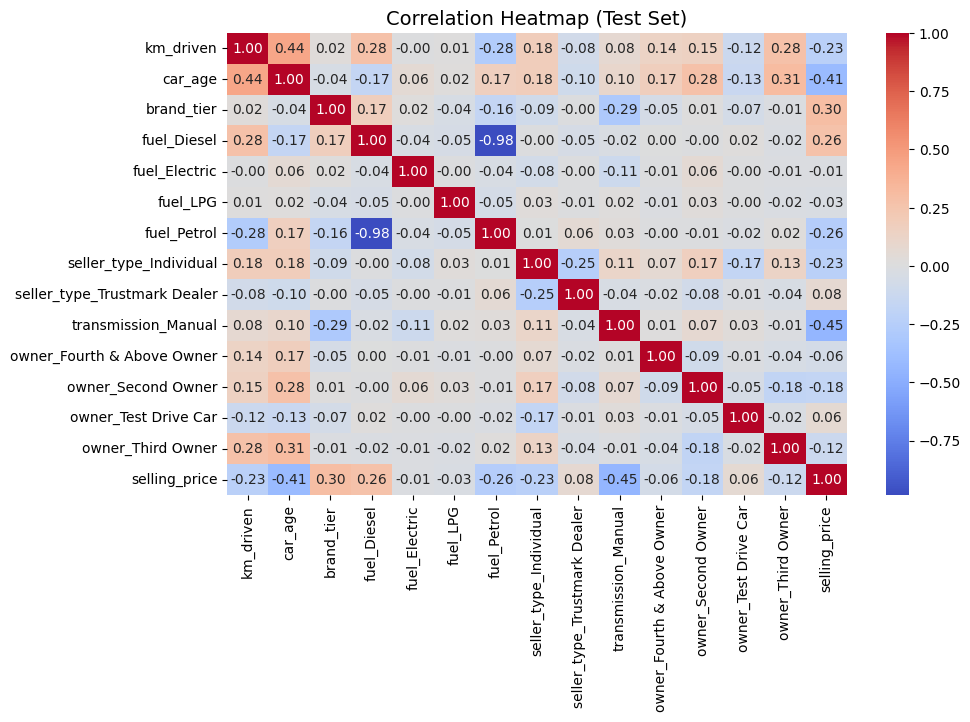

selling_price                   1.000000
brand_tier                      0.297664
fuel_Diesel                     0.264274
seller_type_Trustmark Dealer    0.076964
owner_Test Drive Car            0.064070
fuel_Electric                  -0.011371
fuel_LPG                       -0.027981
owner_Fourth & Above Owner     -0.063802
owner_Third Owner              -0.123055
owner_Second Owner             -0.175179
km_driven                      -0.226105
seller_type_Individual         -0.228758
fuel_Petrol                    -0.258390
car_age                        -0.412448
transmission_Manual            -0.447478
Name: selling_price, dtype: float64


In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Gabungkan kembali X_test dan y_test
test_data = X_test.copy()
test_data["selling_price"] = y_test

# Ambil kolom numerik saja
numeric_test = test_data.select_dtypes(include=['number'])

# Hitung korelasi
corr_test = numeric_test.corr()

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_test, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap (Test Set)", fontsize=14)
plt.show()

# Korelasi tiap fitur terhadap target
target_corr_test = corr_test["selling_price"].sort_values(ascending=False)
print(target_corr_test)


In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["Feature"] = X_reduced.columns
vif_data["VIF"] = [variance_inflation_factor(X_reduced.values, i) for i in range(X_reduced.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))

                         Feature        VIF
1                        car_age  10.179439
8            transmission_Manual   8.017904
6         seller_type_Individual   4.947777
0                      km_driven   4.554530
3                    fuel_Diesel   2.312682
10            owner_Second Owner   1.713170
2                     brand_tier   1.588206
12             owner_Third Owner   1.293084
9     owner_Fourth & Above Owner   1.094967
7   seller_type_Trustmark Dealer   1.030355
11          owner_Test Drive Car   1.024737
5                       fuel_LPG   1.017232
4                  fuel_Electric   1.004961


#Modelling

##Linear Reggression

In [44]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [45]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

coefficients

,Feature,Coefficient
12,owner_Test Drive Car,2.539435e+05
3,fuel_Diesel,2.212079e+05
2,brand_tier,1.180392e+05
8,seller_type_Trustmark Dealer,1.160405e+05
5,fuel_LPG,1.354635e+04
4,fuel_Electric,-5.820766e-11
0,km_driven,-7.737989e-01
6,fuel_Petrol,-1.248449e+04
7,seller_type_Individual,-2.319560e+04
1,car_age,-3.382933e+04


##Ridge Regression

In [46]:
from sklearn.linear_model import Ridge
import pandas as pd

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

Ridge()

In [47]:
ridge_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": ridge_model.coef_
}).sort_values(by="Coefficient", ascending=False)

ridge_coefficients


,Feature,Coefficient
12,owner_Test Drive Car,233308.771890
3,fuel_Diesel,215432.751513
2,brand_tier,118281.855802
8,seller_type_Trustmark Dealer,110657.452788
5,fuel_LPG,7509.608890
4,fuel_Electric,0.000000
0,km_driven,-0.776035
6,fuel_Petrol,-18003.526073
7,seller_type_Individual,-24063.722343
1,car_age,-33894.760517


##Lasso Regression

In [48]:
from sklearn.linear_model import Lasso
import pandas as pd

lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)

Lasso()

In [49]:
lasso_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lasso_model.coef_
}).sort_values(by="Coefficient", ascending=False)

lasso_coefficients

,Feature,Coefficient
12,owner_Test Drive Car,253692.156487
3,fuel_Diesel,221129.614553
2,brand_tier,118038.383319
8,seller_type_Trustmark Dealer,115904.947772
5,fuel_LPG,13326.132419
4,fuel_Electric,0.000000
0,km_driven,-0.773822
6,fuel_Petrol,-12557.539600
7,seller_type_Individual,-23203.057232
1,car_age,-33830.687907


#Model Evaluation

In [50]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# List model yang ingin dibandingkan
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1)
}

# List untuk menyimpan hasil
results_list = []

for name, model in models.items():
    # Fit model
    model.fit(X_train, y_train)

    # Training error
    y_train_pred = model.predict(X_train)
    results_list.append({
        "Model": name,
        "Dataset": "Train",
        "MAE": mean_absolute_error(y_train, y_train_pred),
        "MSE": mean_squared_error(y_train, y_train_pred),
        "RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "R2": r2_score(y_train, y_train_pred)
    })

    # Test error
    y_test_pred = model.predict(X_test)
    results_list.append({
        "Model": name,
        "Dataset": "Test",
        "MAE": mean_absolute_error(y_test, y_test_pred),
        "MSE": mean_squared_error(y_test, y_test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "R2": r2_score(y_test, y_test_pred)
    })

# Convert list ke DataFrame
results = pd.DataFrame(results_list)

# Tampilkan hasil
results


,Model,Dataset,MAE,MSE,RMSE,R2
0,LinearRegression,Train,199316.407630,1.273710e+11,356890.777507,0.477069
1,LinearRegression,Test,209231.186107,1.897367e+11,435587.732711,0.411000
2,Ridge,Train,199307.439436,1.273742e+11,356895.214651,0.477056
3,Ridge,Test,209122.309174,1.897095e+11,435556.593891,0.411084
4,Lasso,Train,199316.390884,1.273710e+11,356890.777517,0.477069
5,Lasso,Test,209231.102071,1.897367e+11,435587.719993,0.411000
